# Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
#--------------------------------
# for Kaggle/Colab
pio.renderers.default = "iframe"
#--------------------------------
# for Github
#pio.renderers.default = "png"

### Pandas Display Settings

In [2]:
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 200)
pd.options.display.float_format = '{:,.2f}'.format

# Load Data

In [3]:
def read_data(file_path, **kwargs):

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"- File not found: {file_path}")

    # Get the extension
    extension = os.path.splitext(file_path)[-1].lower()
    
    print(f"- 📂 Data is being uploaded in '{extension}' format.")

    try:
        if extension == '.csv':
           
            return pd.read_csv(file_path, **kwargs)
        
        elif extension in ['.parquet', '.pq','.gzip', '.gz', '.parquet.gzip']:
            return pd.read_parquet(file_path, **kwargs)
        
        elif extension in ['.feather', '.ftr']:
            return pd.read_feather(file_path, **kwargs)
        
        elif extension == '.json':
            return pd.read_json(file_path, **kwargs)
        
        elif extension in ['.xlsx', '.xls']:
            return pd.read_excel(file_path, **kwargs)
        
        else:
            raise ValueError(f"- Unsupported file format: {extension}")
       
    except FileNotFoundError as e:
        raise Exception(f"- ❌ Error: Please check the file path. \nDetails: {e}")
    
    except pd.errors.EmptyDataError:
        raise Exception("- ❌ Error: The file is empty (EmptyDataError).")
    
    except pd.errors.ParserError:
        raise Exception("- ❌ Error: Invalid file format. Please check the CSV delimiters (sep=',').")
    
    except Exception as e:
       raise Exception(f"- ❌ An unexpected error occurred: {e}")



In [4]:
df_original = read_data(file_path = "student_mental_health_burnout_1M.csv")
df_original.head()

- 📂 Data is being uploaded in '.csv' format.


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.60,6.49,68.41,4.12,2.28,1.99,6.88,2.73,6.47,4.99,4.98,3.45,3.59,2.04,7.07,Low,1.75
1,20,Male,3,5.60,5.63,67.68,0.35,0.00,0.00,7.46,3.69,0.00,3.86,5.14,2.81,5.48,0.00,9.86,Low,0.00
2,29,Male,2,2.58,6.02,58.37,3.48,2.43,0.85,8.95,3.30,6.90,5.43,3.06,4.92,6.07,0.00,7.63,Low,0.70
3,27,Male,4,4.61,6.68,68.93,6.78,4.51,4.29,4.57,2.07,2.35,6.30,6.93,6.92,6.56,7.23,4.65,High,5.38
4,24,Male,4,2.19,4.01,69.14,1.85,1.10,0.00,5.99,4.03,4.51,4.90,5.13,4.38,5.93,0.00,8.93,Low,0.00


In [5]:
df = df_original.copy()

# Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

## Memory Optimization (Downcasting)

### Why we do it?
By default, Pandas allocates the maximum memory size for numerical types (e.g., `int64`, `float64`). For a 1-million-row dataset, this leads to an unnecessarily high RAM footprint.

- **Numeric Downcasting:** We convert 64-bit types to 32-bit or even 8-bit where possible without losing precision. This can reduce the memory usage by up to **70-80%**.
- **Object to Category Conversion:** Storing repetitive strings as `object` is extremely inefficient. Converting them to `category` type stores the unique strings once and uses integer pointers for the rest, significantly speeding up filtering and grouping operations.

In [7]:
def optimize_floats(df):
    """
    Downcasts float64 columns to the smallest possible float subtype to reduce memory usage.

    Args:
        df (pd.DataFrame): The target dataframe.

    Returns:
        pd.DataFrame: Dataframe with optimized float columns.
    """
    floats = df.select_dtypes(include=['float64']).columns
    df[floats] = df[floats].apply(pd.to_numeric, downcast='float')
    return df

In [8]:
def optimize_ints(df):
    """
    Downcasts int64 columns to the smallest possible integer subtype to save memory.

    Args:
        df (pd.DataFrame): The target dataframe.

    Returns:
        pd.DataFrame: Dataframe with optimized integer columns.
    """
    ints = df.select_dtypes(include=['int64']).columns
    df[ints] = df[ints].apply(pd.to_numeric, downcast='integer')
    return df

In [9]:
def optimize_objects_to_categories(df):
    """
    Converts object-type columns to categories to improve performance and reduce RAM footprint.

    Args:
        df (pd.DataFrame): The target dataframe.

    Returns:
        pd.DataFrame: Dataframe with object columns converted to category type.
    """
    objects = df.select_dtypes(include=['object']).columns
    df[objects] = df[objects].astype('category')
    return df

In [10]:
df = optimize_floats(df)
df = optimize_ints(df)
df = optimize_objects_to_categories(df)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   age                   1000000 non-null  int8    
 1   gender                1000000 non-null  category
 2   academic_year         1000000 non-null  int8    
 3   study_hours_per_day   1000000 non-null  float32 
 4   exam_pressure         1000000 non-null  float32 
 5   academic_performance  1000000 non-null  float32 
 6   stress_level          1000000 non-null  float32 
 7   anxiety_score         1000000 non-null  float32 
 8   depression_score      1000000 non-null  float32 
 9   sleep_hours           1000000 non-null  float32 
 10  physical_activity     1000000 non-null  float32 
 11  social_support        1000000 non-null  float32 
 12  screen_time           1000000 non-null  float32 
 13  internet_usage        1000000 non-null  float32 
 14  financial_stress   

In [12]:
df.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,"1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00"
mean,23.00,2.50,5.00,6.00,71.00,4.25,2.99,1.27,6.50,3.01,5.00,5.02,5.04,5.00,5.98,1.78,7.02,1.32
std,3.74,1.12,1.99,1.55,5.66,1.68,1.51,1.22,1.47,1.46,1.98,1.96,2.16,1.98,1.96,1.66,1.31,1.34
min,17.00,1.00,0.00,1.00,42.37,0.00,0.00,0.00,3.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.31,0.00
25%,20.00,2.00,3.65,4.94,67.18,3.10,1.92,0.01,5.49,1.99,3.65,3.65,3.49,3.66,4.65,0.12,6.14,0.00
50%,23.00,3.00,5.00,6.00,71.00,4.24,2.97,1.05,6.50,3.00,5.00,5.00,5.00,5.00,6.00,1.50,7.07,1.01
75%,26.00,4.00,6.35,7.05,74.82,5.39,4.01,2.09,7.51,4.01,6.35,6.35,6.51,6.35,7.35,2.89,7.96,2.17
max,29.00,4.00,14.00,10.00,97.25,10.00,10.00,8.53,10.00,7.00,10.00,12.00,14.00,10.00,10.00,10.00,10.00,9.33


In [13]:
df["gender"].value_counts()

gender
Female    480070
Male      479643
Other      40287
Name: count, dtype: int64

In [14]:
df["risk_level"].value_counts()

risk_level
Low       766645
Medium    218275
High       15080
Name: count, dtype: int64

## Stratified Sampling with Scikit-Learn

### Why we do it?
Visualizing 1 million points in interactive plots (like Plotly) causes significant lag and makes the charts unreadable (overplotting). However, simply taking a random sample might lead to **sampling bias**.

- **The Problem with Random Sampling:** If a critical group (e.g., "High Risk" students) represents only 5% of the total data, a standard random sample might miss them entirely or misrepresent their actual weight.
- **The Stratified Solution:** Using `Stratified Sampling` ensures that our sample (e.g., 50,000 rows) maintains the exact same distribution of `risk_levels` as the original 1,000,000 rows.

In [15]:
def get_stratified_sample_sklearn(df, target_column="risk_level", sample_size=50000):
    """
    Creates a representative sample while maintaining class proportions.

    Args:
        df (pd.DataFrame): The input dataset.
        target_column (str): Column used for stratification.
        sample_size (int): Total number of rows for the output sample.

    Returns:
        pd.DataFrame: A stratified subset of the original data.
    """
    # Calculate the ratio based on the desired sample size
    test_ratio = sample_size / len(df)
    
    # We only care about the 'test' part which will act as our stratified sample
    _, df_sample = train_test_split(
        df,
        test_size=test_ratio,
        stratify=df[target_column],
        random_state=42
    )
    
    return df_sample

# Duplicated Variables

In [16]:
df.duplicated().sum()

np.int64(0)

# Missing Values

In [17]:
def missing_values(data=df):
    """
    Returns a summary of missing values, percentages, and data types for each column.

    Args:
        data (pd.DataFrame): The dataset to analyze.

    Returns:
        pd.DataFrame: Summary table of data quality metrics.
    """
    missing_values = data.isna().sum().reset_index()
    missing_values.columns = ["Columns", "Count"]
    missing_values["Percentage"] = (missing_values["Count"] * 100) / len(data)
    missing_values["Data Type"] = data.dtypes.to_list()
    
    return missing_values

In [18]:
missing_values(df)

,Columns,Count,Percentage,Data Type
0,age,0,0.00,int8
1,gender,0,0.00,category
2,academic_year,0,0.00,int8
3,study_hours_per_day,0,0.00,float32
4,exam_pressure,0,0.00,float32
5,academic_performance,0,0.00,float32
6,stress_level,0,0.00,float32
7,anxiety_score,0,0.00,float32
8,depression_score,0,0.00,float32
9,sleep_hours,0,0.00,float32


# Correlation

In [19]:
# We are creating subset datasets.
df_numerical = df.select_dtypes(include = "number")
df_sample = get_stratified_sample_sklearn(df)
df_sample_small = get_stratified_sample_sklearn(df)

In [20]:
df_corr = df_numerical.corr()
df_corr

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
age,1.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00
academic_year,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00
study_hours_per_day,-0.00,0.00,1.00,0.77,0.39,0.35,0.27,0.22,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.34,-0.34,0.19
exam_pressure,-0.00,0.00,0.77,1.00,0.13,0.46,0.35,0.28,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.43,-0.44,0.24
academic_performance,0.00,0.00,0.39,0.13,1.00,0.06,0.05,0.04,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.06,-0.06,0.03
stress_level,-0.00,0.00,0.35,0.46,0.06,1.00,0.76,0.62,-0.26,-0.17,-0.00,-0.00,-0.00,0.47,0.35,0.75,-0.95,0.55
anxiety_score,-0.00,0.00,0.27,0.35,0.05,0.76,1.00,0.48,-0.20,-0.13,-0.00,-0.00,-0.00,0.35,0.26,0.67,-0.87,0.46
depression_score,-0.00,0.00,0.22,0.28,0.04,0.62,0.48,1.00,-0.17,-0.11,-0.36,0.00,-0.00,0.29,0.21,0.64,-0.76,0.65
sleep_hours,-0.00,-0.00,-0.00,-0.00,-0.00,-0.26,-0.20,-0.17,1.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.37,0.25,-0.19
physical_activity,-0.00,-0.00,0.00,0.00,-0.00,-0.17,-0.13,-0.11,-0.00,1.00,0.00,0.00,0.00,-0.00,0.00,-0.11,0.17,-0.07


#### Correlation Matrix

In [21]:
fig = px.imshow(df_corr, 
                text_auto='.2f', 
                aspect="auto", 
                color_continuous_scale='Jet', 
                title="Correlation Heatmap")

fig.update_layout(
    width=1200,  
    height=800, 
    
   
    margin=dict(l=100, r=120, t=100, b=100), 
    coloraxis_colorbar=dict(
        title="Corr",
        thicknessmode="pixels", thickness=20,
        lenmode="fraction", len=0.8,
        x=1.05,
        y= 0.5
    )
)
fig.update_xaxes(side="bottom", tickangle= -45)
fig.update_layout(coloraxis_colorbar_x=1.05) 
fig.update_traces(xgap=2, ygap=2)

fig.show()

In [22]:
# We check nonlinear correlations using the Spearman (Ordered/Nonlinear) method instead of the Pearson (Linear) method.
df_spearman = df_numerical.corr(method='spearman')
fig = px.imshow(df_spearman, 
                text_auto='.2f', 
                aspect="auto", 
                color_continuous_scale= 'Jet',      #'RdBu_r' other color scale option
                title="Spearman Correlation Heatmap")

fig.update_layout(
    width=1200,   
    height=800,   
    
    margin=dict(l=100, r=120, t=100, b=100), 
    
    coloraxis_colorbar=dict(
        title="Corr",
        thicknessmode="pixels", thickness=20,
        lenmode="fraction", len=0.8,
        x=1.05,
        y= 0.5
    )
)

fig.update_xaxes(side="bottom", tickangle= -45)
fig.update_traces(xgap=2, ygap=2)
fig.update_layout(coloraxis_colorbar_x=1.05) 

fig.show()

#### Statistical Relationship Between Attributes and Dropout Risk

In [23]:
def find_common_correlations(df_sample, target_col="dropout_risk", method = "spearman"):
    correlations = df.select_dtypes(include=[np.number]).corr(method = method)[target_col].sort_values(ascending=False)
    
    corr_df = correlations.to_frame(name="Correlation with Dropout Risk")
    return corr_df

risk_correlations = find_common_correlations(df)
risk_correlations

,Correlation with Dropout Risk
dropout_risk,1.00
burnout_score,0.66
depression_score,0.62
stress_level,0.55
anxiety_score,0.45
financial_stress,0.41
exam_pressure,0.23
study_hours_per_day,0.18
family_expectation,0.13
academic_performance,0.03


#### Plot Style

In [24]:
from matplotlib.colors import LinearSegmentedColormap
sns.set_style("white", {
    "axes.facecolor": "#FAFAFA",  
    "figure.facecolor": "#FFFFFF", 
    "grid.color": "#F0F0F0",       
    "axes.edgecolor": "#D1D1D1",   
    "text.color": "#333333"        
})

colors = ["#E0E0E0", "#4169E1", "#FF4B2B"] 
soft_modern_cmap = LinearSegmentedColormap.from_list("soft_tech", colors, N=256)

#### Depression Level vs Dropout Risk

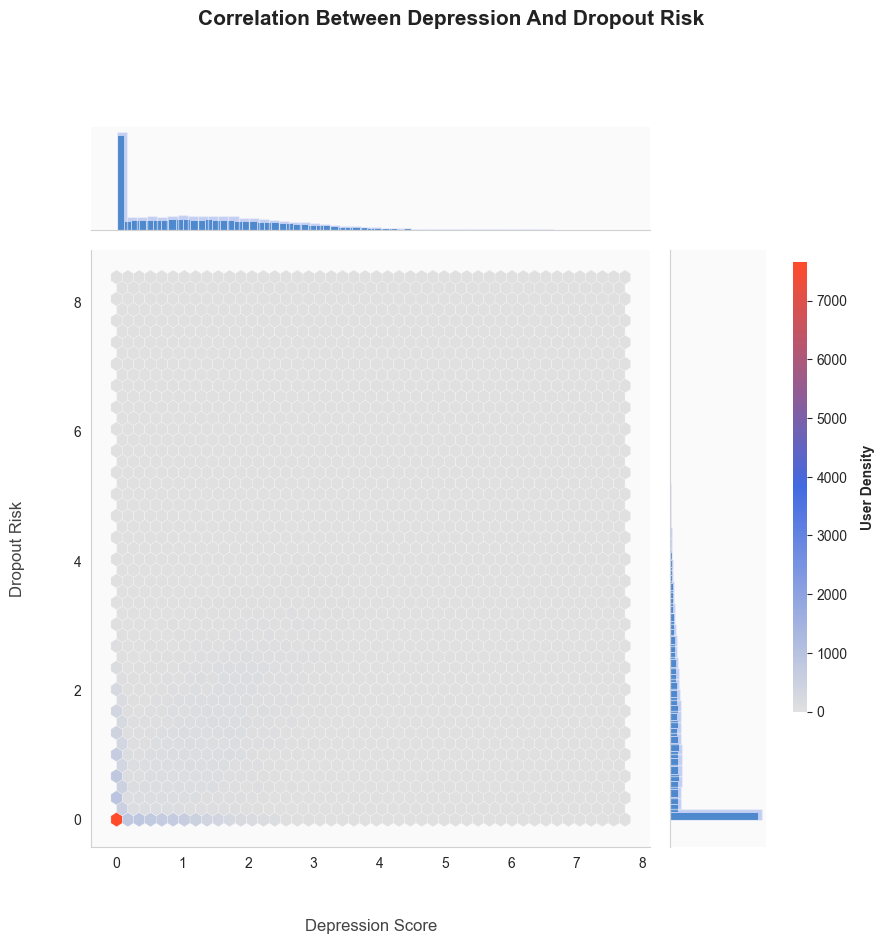

In [25]:
g = sns.jointplot(data=df_sample, x="depression_score", y="dropout_risk", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Depression Score", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Dropout Risk", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df_sample["depression_score"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df_sample["dropout_risk"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Depression And Dropout Risk", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Screen Time vs Interner Usage

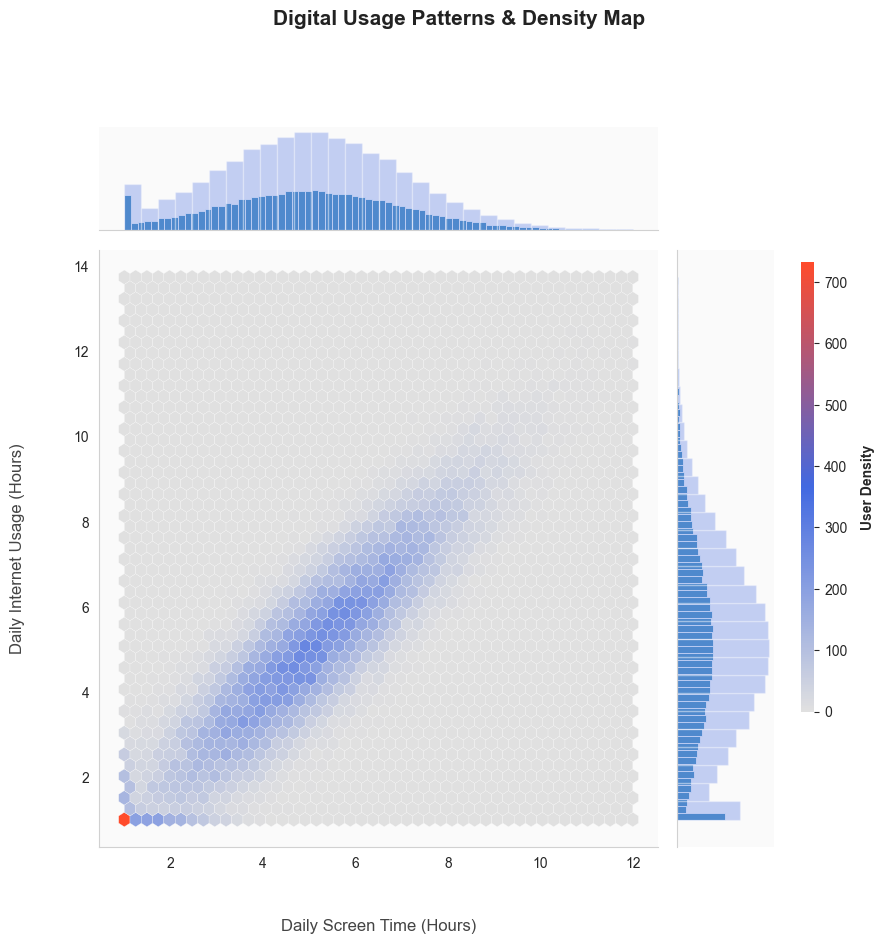

In [26]:
g = sns.jointplot(data=df_sample, x="screen_time", y="internet_usage", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Daha ince bir bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Barın dış çizgisini kaldır

#LABELS
g.ax_joint.set_xlabel("Daily Screen Time (Hours)", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Daily Internet Usage (Hours)", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df_sample["screen_time"], color="#4169E1", alpha=0.3, bins=30, edgecolor='white')
g.ax_marg_y.hist(df_sample["internet_usage"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=30, edgecolor='white')

# TITLE
g.fig.suptitle("Digital Usage Patterns & Density Map", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Burnout Level vs Stress Level

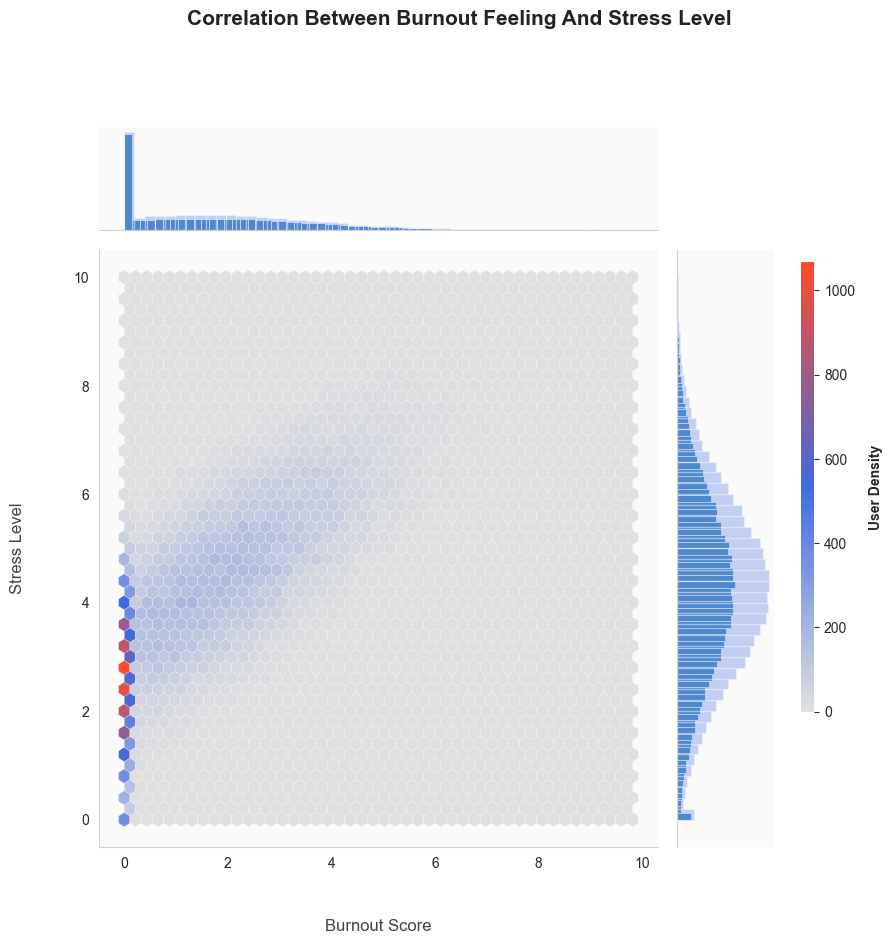

In [27]:
g = sns.jointplot(data=df_sample, x="burnout_score", y="stress_level", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Burnout Score", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Stress Level", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df_sample["burnout_score"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df_sample["stress_level"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Burnout Feeling And Stress Level", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Social Support vs Depression Level

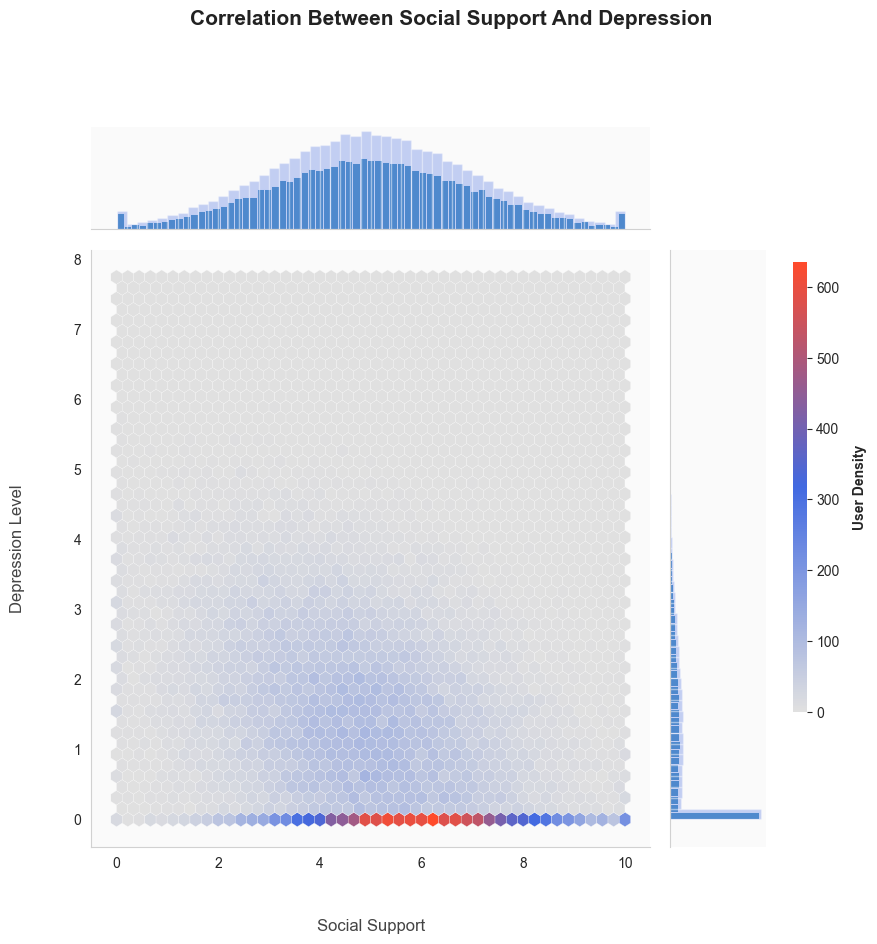

In [28]:
g = sns.jointplot(data=df_sample, x="social_support", y="depression_score", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Social Support", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Depression Level", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df_sample["social_support"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df_sample["depression_score"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Social Support And Depression", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Social Support vs Dropout Risk

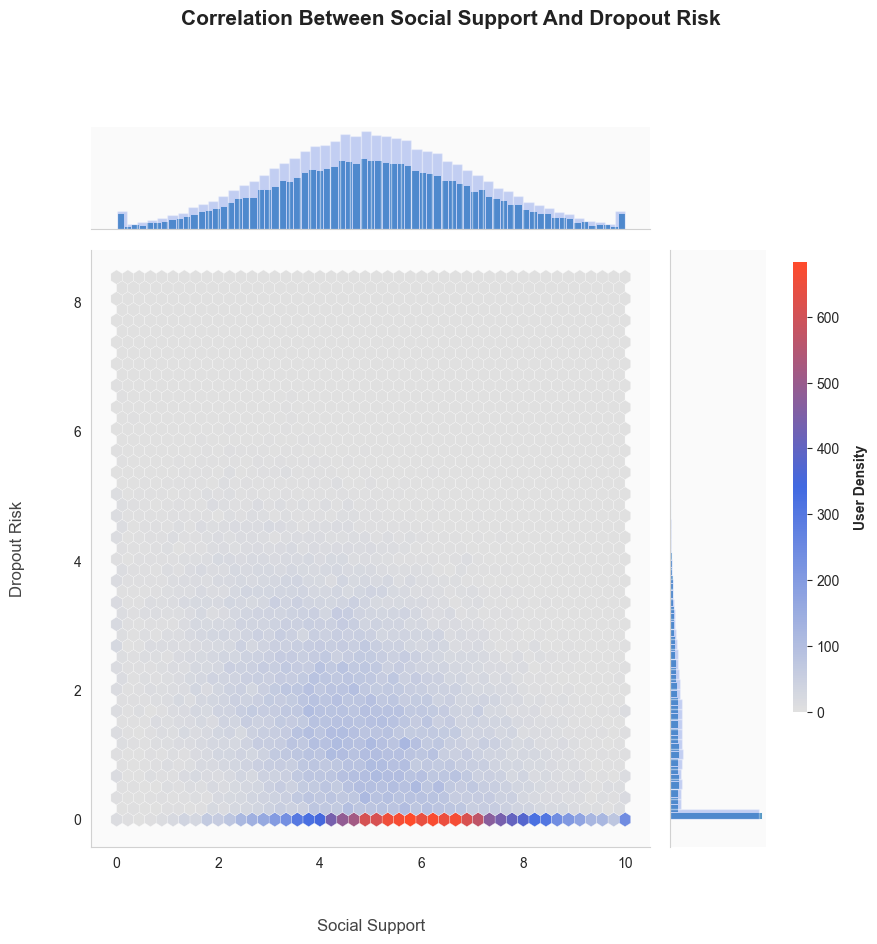

In [29]:
g = sns.jointplot(data=df_sample, x="social_support", y="dropout_risk", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Social Support", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Dropout Risk", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df_sample["social_support"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df_sample["depression_score"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Social Support And Dropout Risk", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()


#### Financial Stress vs Stress Level

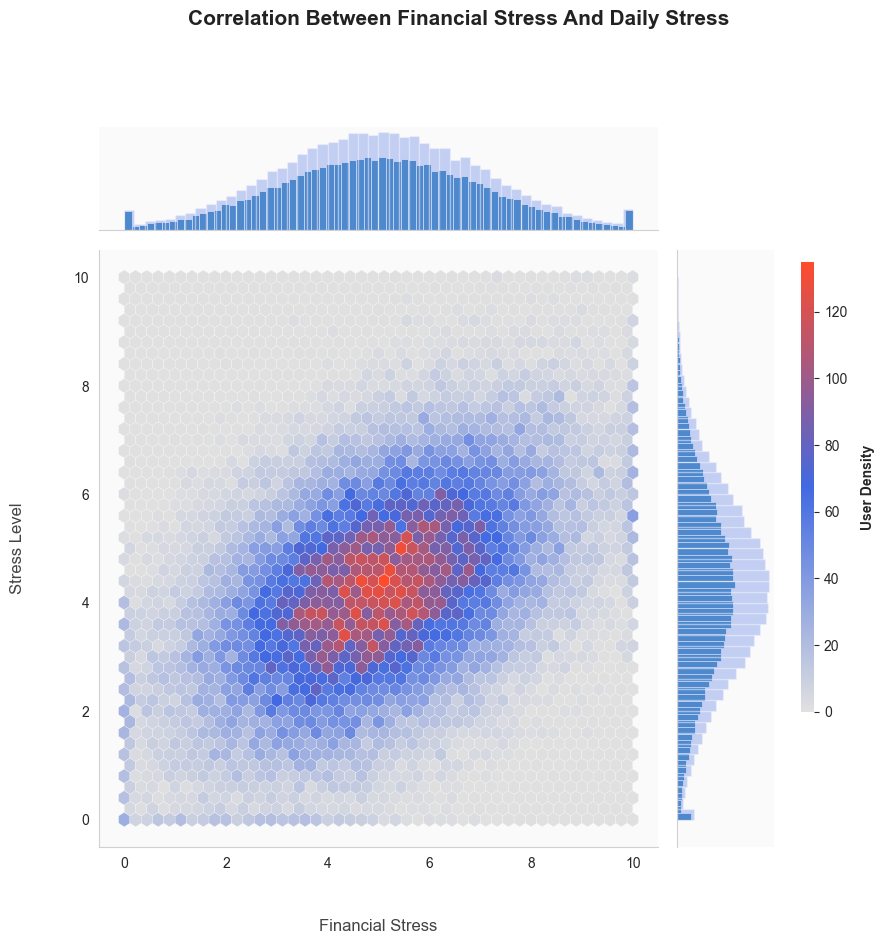

In [30]:
g = sns.jointplot(data=df_sample, x="financial_stress", y="stress_level", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Financial Stress", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Stress Level", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df_sample["financial_stress"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df_sample["stress_level"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Financial Stress And Daily Stress", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Financial Stress vs Dropout Risk

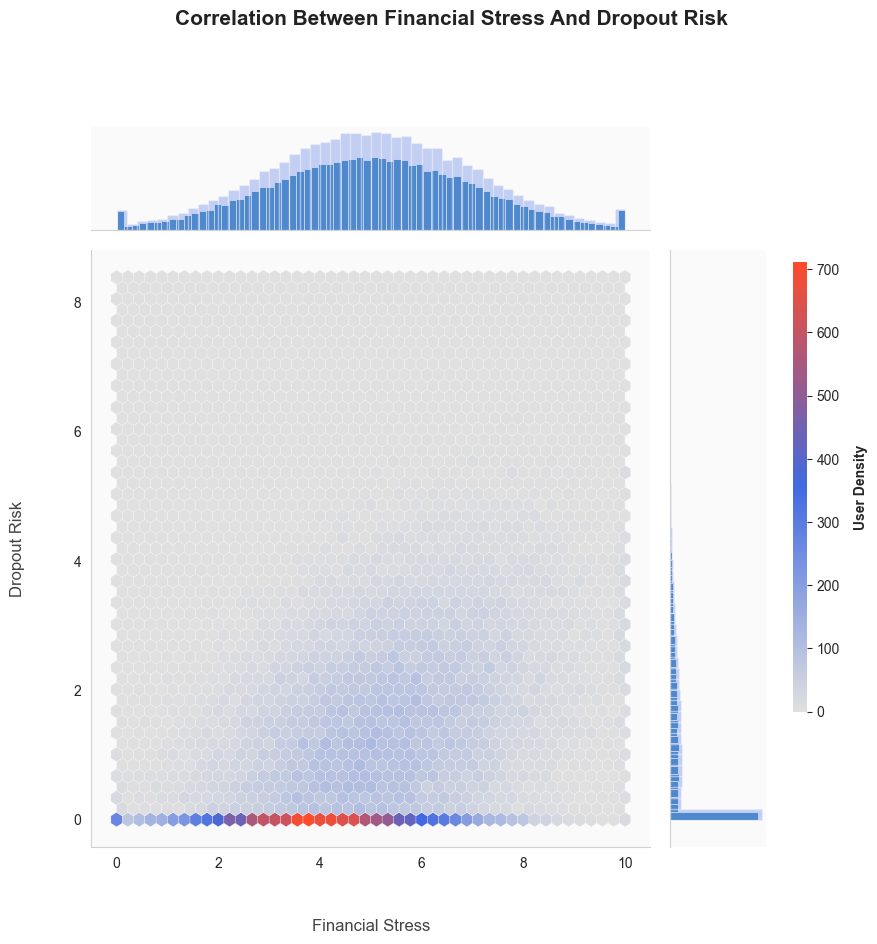

In [31]:
g = sns.jointplot(data=df_sample, x="financial_stress", y="dropout_risk", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Financial Stress", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Dropout Risk", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df_sample["financial_stress"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df_sample["dropout_risk"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Financial Stress And Dropout Risk", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

# 🔍 Correlation Analysis & Feature Insights

This section evaluates the relationships between the feature set and the target variable, **dropout_risk**. By comparing **Pearson** (linear) and **Spearman** (rank-based) correlation coefficients, we have identified the primary psychological, social, and economic drivers of student attrition.

### 1. Key Drivers of Dropout Risk
The analysis reveals a multi-dimensional risk profile where psychological distress and financial instability are the dominant predictors.

| Variable | Correlation (Pearson/Spearman) | Impact Type |
| :--- | :---: | :--- |
| **Burnout Score** | +0.69 | Strong Positive (Primary Driver) |
| **Depression Score** | +0.65 | Strong Positive |
| **Mental Health Index** | -0.63 | Strong Negative (Protective Factor) |
| **Financial Stress** | +0.58 | Moderate-Strong Positive |
| **Stress Level** | +0.55 | Moderate Positive |
| **Social Support** | -0.39 | Moderate Negative |

**Key Insight:** Students are not merely "failing out" due to grades; they are being forced out by a combination of **mental health exhaustion** and **economic pressure**. The high correlation of *Financial Stress* suggests that tuition or cost-of-living concerns act as a significant catalyst for dropout risk.



---

### 2. The "Irrelevant" Features (Noise Detection)
Several variables showed near-zero correlation ($|r| < 0.05$) with dropout risk. These features suggest that, within this specific population, risk is independent of:

* **Demographics & Time:** `age` and `academic_year`.
* **Digital Lifestyle:** `screen_time` and `internet_usage`.
* **Academic Baseline:** Interestingly, `academic_performance` shows a very weak link.

> **Senior Observation:** High academic performance does not insulate a student from risk if psychological and financial stressors are high. Success in the classroom does not equate to stability in enrollment.

---

### 3. Multicollinearity & Redundancy
To optimize model efficiency and prevent overfitting, we identified the following highly collinear pairs:

* **Stress Level vs. Mental Health Index (-0.95):** These are nearly perfect inverses. Including both would introduce redundancy.
* **Screen Time vs. Internet Usage (+0.89):** These variables capture the same behavioral pattern.
* **Burnout Score vs. Depression Score (+0.82):** High overlap indicates these features may be measuring the same underlying psychological exhaustion.

---

### 4. Strategic Recommendations for Modeling
Based on these statistical insights, the following data strategy is recommended:

1.  **Feature Pruning:** Drop `age`, `academic_year`, and `screen_time`. These variables contribute noise rather than signal.
2.  **Dimensionality Reduction:** Consider an interaction term between `Financial Stress` and `Social Support`, as these likely moderate each other's impact.
3.  **Priority Interventions:** Strategy should shift from "Academic Tutoring" to **"Financial Aid & Mental Health Counseling,"** as these domains show the highest statistical impact on retention.
4.  **Model Selection:** Since Spearman and Pearson coefficients are nearly identical, the relationships are largely linear. We can confidently utilize **Logistic Regression** as a baseline, though **Tree-based models** (like XGBoost) may better capture complex interactions.

# Outliers

In [32]:
dddf_sample = get_stratified_sample_sklearn(df, target_column="risk_level", sample_size=10000)

In [33]:
numeric_cols = df_numerical.columns
n_cols = 2
n_rows = (len(numeric_cols) + 1) // 2 # Automatically calculates rows based on column number.

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=numeric_cols,
    vertical_spacing=0.02, 
    horizontal_spacing=0.1
)

for index, col_name in enumerate(numeric_cols):
    row = (index // n_cols) + 1
    col = (index % n_cols) + 1
    
    fig.add_trace(
        go.Box(
            y=df_sample[col_name], 
            name="", # Prevents name clutter on the X-axis
            marker_color='royalblue', 
            boxmean=True, # Adds an average line (dashed line)
            boxpoints='outliers', # Only displays extreme values as decimal points.
            quartilemethod="linear"
        ),
        row=row, col=col
    )

fig.update_layout(
    height=300 * n_rows, # Adjusts height according to row count
    width=900,
    title_text="Outlier Analysis",
    title_x=0.5,
    showlegend=False,
    template="plotly_white"
)

fig.show()

In [34]:
numeric_cols = df_numerical.columns.tolist()

# Exclude target variable from the list to avoid self-correlation plot
target = 'dropout_risk'
features = [col for col in numeric_cols if col != target]

# Dynamic Subplot Structure
rows = (len(features) + 1) // 2
fig = make_subplots(
    rows=rows, cols=2,
    subplot_titles=features,
    vertical_spacing=0.04, 
    horizontal_spacing=0.08
)

# Adding Scatter Plots with Loop
for index, col_name in enumerate(features):
    row = (index // 2) + 1
    col = (index % 2) + 1
    
    fig.add_trace(
        go.Scattergl(
            x=df_sample[col_name],      # Feature on X-axis (e.g., Stress)
            y=df_sample[target],        # Risk score on Y-axis
            mode='markers',
            name=col_name,
            marker=dict(
                size=4, 
                opacity=0.4,            # Transparency is essential to visualize density
                color='royalblue',
                line=dict(width=0)      # No borders for a cleaner look
            )
        ),
        row=row, col=col
    )

# Layout Adjustments
fig.update_layout(
    height=350 * rows, 
    width=1000,
    title_text="<b>Feature Analysis: Relationship with Dropout Risk</b>",
    title_x=0.5,
    title_font_size=22,
    showlegend=False,
    template="plotly_white",
    margin=dict(t=120, b=50, l=50, r=50)
)

# Improve axis readability
fig.update_xaxes(showgrid=True, gridcolor='whitesmoke')
fig.update_yaxes(title_text="Risk Score", showgrid=True, gridcolor='whitesmoke')

fig.show()

In [35]:
def data_distribution_stats(data=df):
    numeric_df = data.select_dtypes(include=[np.number])
    cols = numeric_df.columns
    
    np_data = numeric_df.values
    
    means = np.nanmean(np_data, axis=0) 
    skews = skew(np_data, axis=0, nan_policy='omit')
    kurtos = kurtosis(np_data, axis=0, nan_policy='omit')
    
    stats_df = pd.DataFrame({
        "Columns": cols,
        "Mean": means,
        "Skew": skews,
        "Kurtosis": kurtos
    })
    
    return stats_df.reset_index(drop=True)


dist_stats = data_distribution_stats(df_sample)
dist_stats

,Columns,Mean,Skew,Kurtosis
0,age,22.99,0.01,-1.23
1,academic_year,2.50,0.00,-1.36
2,study_hours_per_day,5.01,0.04,-0.13
3,exam_pressure,6.00,-0.02,-0.15
4,academic_performance,71.00,-0.02,0.00
5,stress_level,4.25,0.02,-0.13
6,anxiety_score,2.99,0.14,-0.29
7,depression_score,1.27,0.83,0.10
8,sleep_hours,6.51,0.00,-0.32
9,physical_activity,3.00,0.09,-0.35


In [36]:
def outlier_analysis(data=df):
    
    numeric_df = data.select_dtypes(include=[np.number])
    outlier_list = []
    total_rows = len(data)

    for col in numeric_df.columns:
        # Quartile calculation with NumPy (For speed)
        q1 = np.nanpercentile(data[col], 25)
        q3 = np.nanpercentile(data[col], 75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Let's count those outside the borders
        lower_outliers = np.sum(data[col] < lower_bound)
        upper_outliers = np.sum(data[col] > upper_bound)
        total_outliers = lower_outliers + upper_outliers
        percentage = (total_outliers / total_rows) * 100
        
        outlier_list.append({
            "Column": col,
            "Lower Outliers": lower_outliers,
            "Upper Outliers": upper_outliers,
            "Total Outliers": total_outliers,
            "Percentage (%)": round(percentage, 4)
        })
    
   
    return pd.DataFrame(outlier_list)

outlier_df = outlier_analysis(df_sample)
outlier_df

,Column,Lower Outliers,Upper Outliers,Total Outliers,Percentage (%)
0,age,0,0,0,0.00
1,academic_year,0,0,0,0.00
2,study_hours_per_day,0,174,174,0.35
3,exam_pressure,165,0,165,0.33
4,academic_performance,197,153,350,0.70
5,stress_level,0,173,173,0.35
6,anxiety_score,0,171,171,0.34
7,depression_score,0,174,174,0.35
8,sleep_hours,0,0,0,0.00
9,physical_activity,0,0,0,0.00


# Asking Question About Data

- Distribution of school dropout risk by gender
- Statistical table of mental states by gender
- Risk Level Distribution
- Mental Health Metrics by Risk Level (Mean Values)
- Impact of Sleep Duration on Stress Levels
- Distribution Of Academic Performance


In [37]:
mental_condition_map = ["stress_level","anxiety_score","depression_score","burnout_score","mental_health_index"]

In [38]:
fig = px.histogram(df_sample, x="dropout_risk", y= "dropout_risk", color="gender", marginal="rug",
                   hover_data=df.columns)
fig.show()

In [39]:
df_sample.groupby(by ="gender",observed=True)[mental_condition_map].agg(['min','max','mean']).T

gender                    Female  Male  Other
stress_level        min     0.00  0.00   0.00
                    max    10.00 10.00   9.67
                    mean    4.25  4.25   4.24
anxiety_score       min     0.00  0.00   0.00
                    max     9.18  8.99   8.09
                    mean    2.99  2.99   2.98
depression_score    min     0.00  0.00   0.00
                    max     7.74  7.03   5.76
                    mean    1.28  1.27   1.26
burnout_score       min     0.00  0.00   0.00
                    max     9.53  9.82   7.67
                    mean    1.79  1.80   1.83
mental_health_index min     1.94  1.61   2.38
                    max    10.00 10.00  10.00
                    mean    7.02  7.02   7.03

In [40]:
df_financial = df_sample.groupby(by = "risk_level",observed=True)["financial_stress"]\
                 .mean()\
                 .reset_index()
df_financial.columns = ["risk_level", "mean_value"]
df_financial

,risk_level,mean_value
0,High,6.52
1,Low,4.76
2,Medium,5.76


In [41]:
fig = px.bar(df_financial, x="risk_level", y="mean_value")
fig.update_traces(marker_color='royalblue')

fig.show()

In [42]:
df_mental_condition = df_sample.sort_values(by = "risk_level", ascending = True)\
.groupby(by = "risk_level", observed=True)[mental_condition_map]\
.agg("mean")\
.rename_axis(None, axis=0)
df_mental_condition.T

,High,Low,Medium
stress_level,7.52,3.72,5.88
anxiety_score,5.69,2.57,4.28
depression_score,3.67,0.93,2.32
burnout_score,6.73,1.06,4.04
mental_health_index,4.19,7.46,5.67


In [43]:
df_mental_condition = df_sample.groupby("risk_level", observed=True)[mental_condition_map]\
    .mean()\
    .reindex(["Low", "Medium", "High"]) # We arrange the categories in a logical order.

fig = go.Figure()

# Categories (X-axis): Low, Medium, High
categories = df_mental_condition.index

# We add a bar for each metric (stress_level, anxiety_score, etc.)
for metric in df_mental_condition.columns:
    fig.add_trace(go.Bar(
        x = categories,
        y = df_mental_condition[metric],
        name = metric.replace("_", " ").title(),
        text = df_mental_condition[metric].round(2), # Write the values on the bar.
        textposition = 'auto'
    ))

fig.update_layout(
    title = "Mental Health Metrics by Risk Level (Mean Values)",
    xaxis_title = "Student Risk Level",
    yaxis_title = "Average Score",
    barmode = 'group', 
    template = "plotly_white",
    legend_title = "Metrics",
    hovermode = "x unified"
)

fig.show()

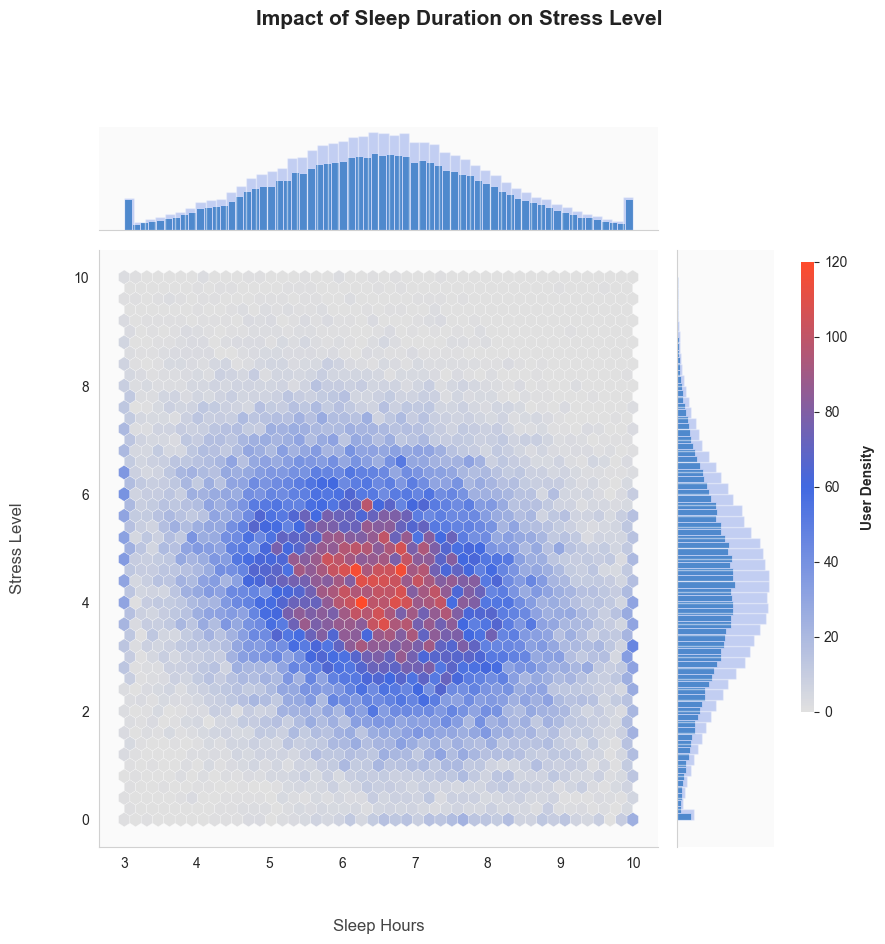

In [44]:
g = sns.jointplot(data=df_sample, x="sleep_hours", y="stress_level", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Sleep Hours", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Stress Level", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df_sample["sleep_hours"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df_sample["stress_level"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Impact of Sleep Duration on Stress Level", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

In [45]:
fig = go.Figure(data = px.histogram(df_sample["academic_performance"]))
fig.show()